# 01 · The delivered data — Smart-Meter-Abdeckung

**Report-Unterkapitel:** Data Understanding → *The delivered data*
**Datenquelle:** `data/raw/smart_meter_daily/` (156 CSV-Dateien, unveränderte Lieferung)

**Frage, die die Abbildung beantwortet:** *Was wurde real geliefert — wie viele
Zählpunkte, über welchen Zeitraum, wie gleichzeitig, wie lückig?*

Die naheliegende Lesart von „Abdeckung" (räumlich: Region/Netzgebiet) ist mit
diesen Daten nicht darstellbar: Es gibt keine Geo-Dimension, nur 8 anonymisierte
Wetterstations-IDs mit stark schiefer Zuordnung (Hg: 59, 8jB: 56, … sV3mR: 2
Haushalte). Die Abdeckung gegen das Gesamtprogramm (156 von 1.298 Haushalten in
der Overview-Datei) ist ein einzelner Satz, kein Plot. Was dagegen echten
Informationsgehalt hat und in keiner Tabelle transportierbar ist, ist die
**zeitliche Abdeckung**: Die 156 Historien starten und enden verteilt über
2018–2024, **nie liefern mehr als 67 Haushalte gleichzeitig**, 41 Historien
haben innere Kalenderlücken (bis 333 Tage), und 3 Haushalte liefern Zeilen ganz
ohne Zielwert.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo-Wurzel relativ zum Notebook (notebooks/data_understanding/ -> Root)
ROOT = Path("..") / ".."
RAW = ROOT / "data" / "raw"
IMAGES = ROOT / "images" / "data_understanding"
IMAGES.mkdir(parents=True, exist_ok=True)

# Farb- und Textrollen (validierte Referenzpalette, Light Mode)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#ffffff"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": BASE,
    "xtick.color": BASE, "ytick.color": BASE,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.8,
    "axes.labelsize": 10.5, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "figure.dpi": 110,
})


def export(fig, name):
    """Jede Abbildung als Vektor-PDF (Report) und PNG (Vorschau) ablegen."""
    fig.savefig(IMAGES / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(IMAGES / f"{name}.png", bbox_inches="tight", dpi=200)
    print(f"exportiert: images/data_understanding/{name}.(pdf|png)")

In [2]:
# Rohdaten laden: 156 Haushalts-CSVs (Semikolon-getrennt), IDs als String
files = sorted((RAW / "smart_meter_daily").glob("*.csv"))
sm = pd.concat(
    [pd.read_csv(f, sep=";", dtype={"Household_ID": str}) for f in files],
    ignore_index=True,
)
sm["date"] = (
    pd.to_datetime(sm["Timestamp"], utc=True).dt.normalize().dt.tz_localize(None)
)
TGT = "kWh_received_Total"
print(f"{len(files)} Dateien | {len(sm):,} Zeilen | {sm['Household_ID'].nunique()} Haushalte")
print(f"Zeitraum: {sm['date'].min().date()} bis {sm['date'].max().date()}")

156 Dateien | 88,791 Zeilen | 156 Haushalte
Zeitraum: 2018-11-02 bis 2024-03-20


In [3]:
# Kennzahlen je Haushalt und je Kalendertag
g = sm.groupby("Household_ID")
per_hh = pd.DataFrame({
    "first": g["date"].min(),
    "last": g["date"].max(),
    "n_rows": g.size(),
    "n_target": g[TGT].count(),
})
per_hh["span"] = (per_hh["last"] - per_hh["first"]).dt.days + 1
per_hh["gap_days"] = per_hh["span"] - per_hh["n_rows"]

daily_count = sm.groupby("date").size()

print(f"Historienlänge: min {per_hh.n_rows.min()}, Median {per_hh.n_rows.median():.0f}, "
      f"max {per_hh.n_rows.max()} Tage")
print(f"Haushalte mit < 365 Tagen: {(per_hh.n_rows < 365).sum()}")
print(f"Haushalte mit Kalenderlücken: {(per_hh.gap_days > 0).sum()} "
      f"(max. {per_hh.gap_days.max()} Tage am Stück fehlend)")
print(f"Maximal gleichzeitig liefernd: {daily_count.max()} Haushalte "
      f"({daily_count.idxmax().date()})")
print(f"Haushalte ohne jeden Zielwert: {sorted(per_hh.index[per_hh.n_target == 0])}")

Historienlänge: min 5, Median 492, max 1846 Tage
Haushalte mit < 365 Tagen: 57
Haushalte mit Kalenderlücken: 41 (max. 333 Tage am Stück fehlend)
Maximal gleichzeitig liefernd: 67 Haushalte (2023-12-08)
Haushalte ohne jeden Zielwert: ['747511', '768498', '996610']


## Abbildungen: Abdeckung der gelieferten Zählpunkte über die Zeit

Drei separate Abbildungen mit identischer Zeitachse:

1. **Aktive Haushalte je Tag** — Anzahl der an jedem Kalendertag tatsächlich
   liefernden Haushalte; der Train/Test-Cutoff der Pipeline (2023-06-30) ist
   markiert, weil die Kurve direkt erklärt, warum nur 71 der 153 modellierten
   Haushalte Testzeilen haben.
2. **Recording-Coverage (Lieferung)** — eine Zeile je Haushalt, von unten nach
   oben nach Lieferbeginn sortiert (früheste Starts unten): dunkle Segmente =
   Tage mit gelieferter Zeile, weiß = keine Lieferung. Innere Kalenderlücken
   erscheinen als weiße Unterbrechungen und sind selbsterklärend — sie
   bekommen keinen Legendeneintrag.
3. **Nutzbare Historie (Zielwert)** — gleiche Anordnung, aber dunkel = Tage
   mit beobachtetem Zielwert; hell = Rest des Aufzeichnungsfensters ohne
   Zielwert. Kalenderlücken und gelieferte Zeilen ohne Target fallen bewusst
   in eine Kategorie: Für das Modell zählt nur, ob an dem Tag ein Zielwert
   vorliegt. Erst hier werden die 3 Haushalte ganz ohne Zielwert sichtbar.

*Verworfene Alternativen:* Heatmap Haushalt × Monat (verschmiert die exakten
Lückenkanten), kumulative Enrollment-Kurve (zeigt Abgänge nicht), Stacked Area
nach Station (Stations-IDs tragen hier nichts). Farben: 1 Slot der validierten
Referenzpalette plus neutrales Grau für „target missing".

exportiert: images/data_understanding/01_delivered_daily_active_households.(pdf|png)


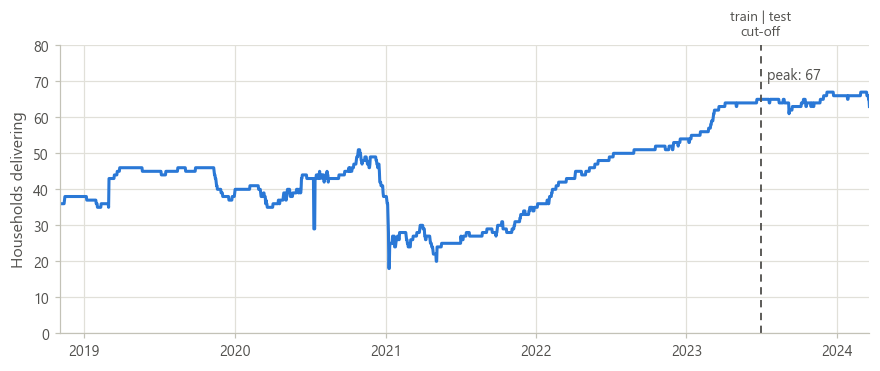

In [4]:
# Abbildung 1: Anzahl aktiv liefernder Haushalte je Kalendertag
all_days = pd.date_range(sm["date"].min(), sm["date"].max(), freq="D")
CUTOFF = pd.Timestamp("2023-06-30")


def year_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlim(all_days[0], all_days[-1])


def mark_cutoff(ax):
    ax.axvline(CUTOFF, color=INK2, lw=1.2, ls=(0, (4, 3)))
    ax.annotate("train | test\ncut-off", xy=(CUTOFF, 1.0),
                xycoords=("data", "axes fraction"),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, color=INK2)


counts = daily_count.reindex(all_days, fill_value=0)

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.plot(counts.index, counts.values, color=BLUE, lw=2, solid_joinstyle="round")
ax.set_ylabel("Households delivering")
ax.set_ylim(0, 80)
peak_day, peak_val = counts.idxmax(), counts.max()
ax.annotate(f"peak: {peak_val}", xy=(peak_day, peak_val),
            xytext=(-4, 8), textcoords="offset points",
            ha="right", fontsize=9.5, color=INK2)
mark_cutoff(ax)
year_axis(ax)

export(fig, "01_delivered_daily_active_households")
plt.show()

exportiert: images/data_understanding/01_delivered_recording_coverage.(pdf|png)


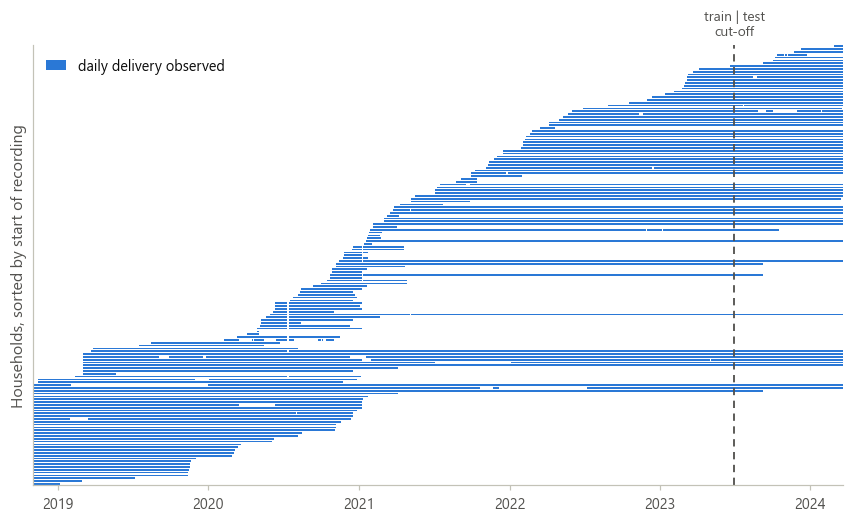

In [5]:
# Abbildung 2: Recording-Coverage — eine Zeile je Haushalt (früheste Starts unten),
# dunkle Segmente = Tage mit gelieferter Zeile, weiß = keine Lieferung
from matplotlib.patches import Patch

day_pos = pd.Series(np.arange(len(all_days)), index=all_days)
day_num = mdates.date2num(all_days)
order = per_hh.sort_values(["first", "last"]).index

M = np.zeros((len(order), len(all_days)), dtype=bool)
for r, hh in enumerate(order):
    M[r, day_pos[sm.loc[sm["Household_ID"] == hh, "date"]].to_numpy()] = True

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for r in range(len(order)):
    edges = np.flatnonzero(np.diff(np.concatenate(([False], M[r], [False]))))
    starts, ends = edges[::2], edges[1::2]
    ax.broken_barh(
        [(day_num[s], e - s) for s, e in zip(starts, ends)],
        (r + 0.2, 0.6), facecolor=BLUE, linewidth=0,
    )
ax.set_ylabel("Households, sorted by start of recording")
ax.set_ylim(0, len(order))
ax.set_yticks([])
ax.grid(False)

mark_cutoff(ax)
year_axis(ax)

ax.legend(handles=[Patch(facecolor=BLUE, label="daily delivery observed")],
          loc="upper left", handlelength=1.4, handleheight=0.7)

export(fig, "01_delivered_recording_coverage")
plt.show()

exportiert: images/data_understanding/01_delivered_usable_history.(pdf|png)


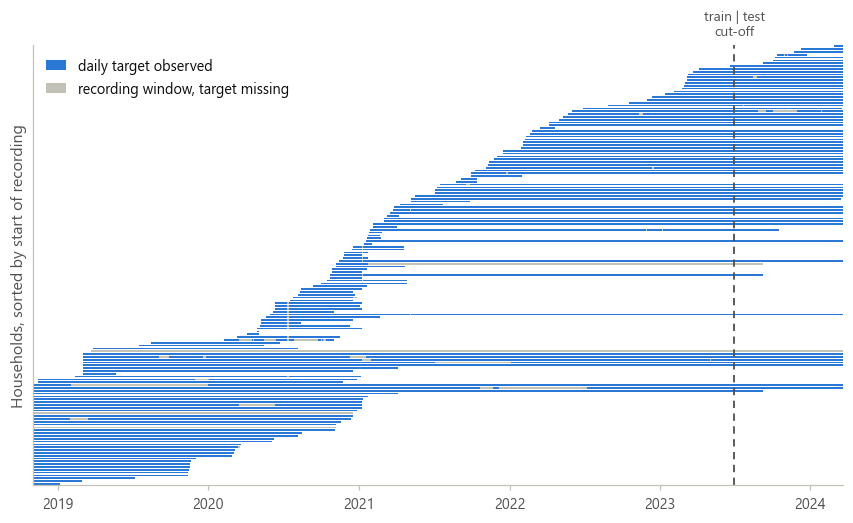

In [6]:
# Abbildung 3: Nutzbare Historie — dunkel = Tag mit beobachtetem Zielwert,
# hell = Aufzeichnungsfenster ohne Zielwert (Kalenderlücken und Zeilen ohne Target)
T = np.zeros((len(order), len(all_days)), dtype=bool)
for r, hh in enumerate(order):
    d = sm.loc[sm["Household_ID"] == hh, ["date", TGT]]
    T[r, day_pos[d.loc[d[TGT].notna(), "date"]].to_numpy()] = True

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for r, hh in enumerate(order):
    w0 = day_pos[per_hh.loc[hh, "first"]]
    w1 = day_pos[per_hh.loc[hh, "last"]]
    ax.broken_barh([(day_num[w0], w1 - w0 + 1)], (r + 0.2, 0.6),
                   facecolor=BASE, linewidth=0)
    edges = np.flatnonzero(np.diff(np.concatenate(([False], T[r], [False]))))
    ax.broken_barh(
        [(day_num[s], e - s) for s, e in zip(edges[::2], edges[1::2])],
        (r + 0.2, 0.6), facecolor=BLUE, linewidth=0,
    )
ax.set_ylabel("Households, sorted by start of recording")
ax.set_ylim(0, len(order))
ax.set_yticks([])
ax.grid(False)

mark_cutoff(ax)
year_axis(ax)

ax.legend(handles=[
    Patch(facecolor=BLUE, label="daily target observed"),
    Patch(facecolor=BASE, label="recording window, target missing"),
], loc="upper left", handlelength=1.4, handleheight=0.7)

export(fig, "01_delivered_usable_history")
plt.show()

## Lesart

- **Gestaffelte Kohorten statt Paneldesign:** Die Lieferung ist kein
  gleichzeitiger Beobachtungszeitraum, sondern ein rollierendes Programm —
  Starts von Ende 2018 bis 2024, viele Historien enden 2020/2021.
- **Nie mehr als 67 gleichzeitig:** Trotz 156 gelieferter Zählpunkte liegt die
  tägliche Abdeckung zwischen 25 und 67 Haushalten. Jede flottenweite Kennzahl
  mischt also wechselnde Teilmengen.
- **Der Cutoff 2023-06-30 teilt ungleich:** Rechts vom Cutoff liefern nur noch
  die zuletzt aktiven Haushalte — deshalb haben nur 71 der 153 Haushalte
  Testzeilen.
- **Zeilen ohne Zielwert:** 3 Haushalte liefern ausschließlich Zeilen ohne
  Zielwert (werden in Stufe 1 der Pipeline entfernt), ein vierter (`816910`)
  fast nur solche — in der dritten Abbildung als durchgehend helle Balken
  sichtbar.
- Die weißen bzw. hellen Unterbrechungen innerhalb der Balken sind die 41
  Historien mit Kalenderlücken — der Grund für das Kalender-Reindexing in
  Stufe 2.